# A Minimal Recurrent Neural Network (RNN)

This demo teaches an RNN to predict the **next point of a sine wave** from the previous 20 points. It uses one recurrent layer and one linear layer.

At each time step, an RNN updates its hidden state (memory):

$$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$$

We use the final hidden state $h_T$ to predict the next value. Unlike a Transformer, the RNN processes the sequence one step at a time.

In [6]:
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


## 1. Make a tiny sequence dataset

Each input contains 20 consecutive sine values. Its target is the value immediately after them. The demo needs no downloaded data.

X shape: torch.Size([980, 20, 1]) = [samples, time steps, features]
y shape: torch.Size([980, 1]) = [samples, output features]


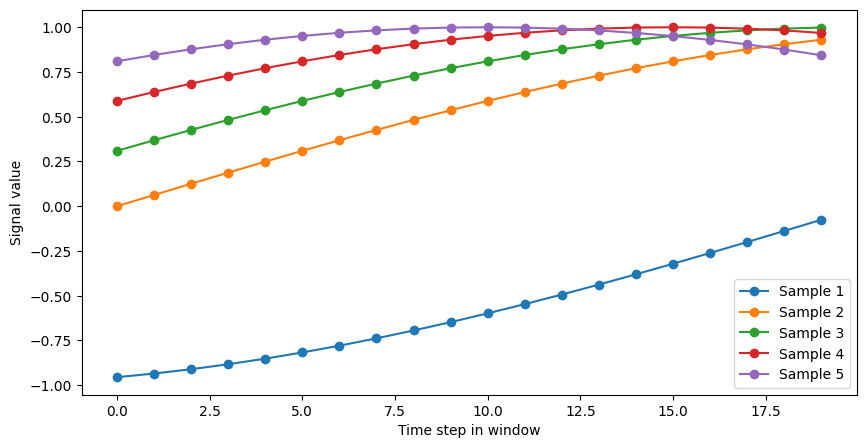

In [ ]:
sequence_length = 20
t = torch.linspace(0, 20 * torch.pi, 1000)
signal = torch.sin(t)

# Sliding windows: [x_t, ..., x_(t+19)] -> x_(t+20)
X = signal.unfold(0, sequence_length, 1)[:-1].unsqueeze(-1)
y = signal[sequence_length:].unsqueeze(-1)

split = int(0.8 * len(X))
X_train, y_train = X[:split].to(device), y[:split].to(device)
X_test, y_test = X[split:].to(device), y[split:].to(device)

print("X shape:", X.shape, "= [samples, time steps, features]")
print("y shape:", y.shape, "= [samples, output features]")

plt.figure(figsize=(10, 5))

for i in range(5):
    sample = X_train[-5 + i].cpu().squeeze(-1)  # (20,)
    plt.plot(sample, marker="o", label=f"Sample {i + 1}")

plt.xlabel("Time step in window")
plt.ylabel("Signal value")
plt.legend()
plt.show()


## 2. Define the model

`nn.RNN` returns a state at every time step plus the final hidden state. We only need the final state for this many-to-one task.

In [8]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,       # one value per time step
            hidden_size=hidden_size,
            batch_first=True,   # [batch, time, features]
        )
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        all_states, final_state = self.rnn(x)
        # final_state: [layers, batch, hidden_size]
        return self.output(final_state[-1])

model = SimpleRNN().to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleRNN(
  (rnn): RNN(1, 16, batch_first=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)
Trainable parameters: 321


## 2b. The same RNN without `nn.RNN`

This version exposes the operation performed at every time step:

$$h_t = \tanh(x_t W_{xh} + h_{t-1}W_{hh} + b_h)$$

All weights are registered with `nn.Parameter`, so PyTorch autograd can still train them.

In [9]:
class RNNFromScratch(nn.Module):
    def __init__(self, hidden_size=16):
        super().__init__()
        self.hidden_size = hidden_size

        # Parameters used in the recurrent equation.
        self.W_xh = nn.Parameter(torch.empty(1, hidden_size))
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size))
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # Parameters used to map the final hidden state to one output.
        self.W_hy = nn.Parameter(torch.empty(hidden_size, 1))
        self.b_y = nn.Parameter(torch.zeros(1))

        bound = 1 / hidden_size**0.5
        nn.init.uniform_(self.W_xh, -bound, bound)
        nn.init.uniform_(self.W_hh, -bound, bound)
        nn.init.uniform_(self.W_hy, -bound, bound)

    def forward(self, x):
        # Initial hidden state h_0: [batch, hidden_size]
        h = x.new_zeros(x.shape[0], self.hidden_size)

        # Explicitly process one time step at a time.
        for step in range(x.shape[1]):
            x_t = x[:, step, :]
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)

        return h @ self.W_hy + self.b_y

manual_model = RNNFromScratch().to(device)
print(manual_model)
print(f"Trainable parameters: {sum(p.numel() for p in manual_model.parameters()):,}")

RNNFromScratch()
Trainable parameters: 305


## 3. Train

Mean squared error compares the predicted and true next value. For clarity, this tiny dataset is trained as one batch.

In [10]:
loss_fn = nn.MSELoss()

def train(model, name, epochs=101):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    model.train()

    for epoch in range(epochs):
        prediction = model(X_train)
        loss = loss_fn(prediction, y_train)

        optimizer.zero_grad()
        loss.backward()       # backpropagation through time
        optimizer.step()
        losses.append(loss.item())

        if epoch % 20 == 0:
            print(f"{name:12s} | epoch {epoch:3d} | MSE: {loss.item():.6f}")
    return losses

losses_builtin = train(model, "nn.RNN")
losses_manual = train(manual_model, "from scratch")

nn.RNN       | epoch   0 | MSE: 0.645907
nn.RNN       | epoch  20 | MSE: 0.030931
nn.RNN       | epoch  40 | MSE: 0.002839
nn.RNN       | epoch  60 | MSE: 0.000987
nn.RNN       | epoch  80 | MSE: 0.000385
nn.RNN       | epoch 100 | MSE: 0.000240
from scratch | epoch   0 | MSE: 0.695861
from scratch | epoch  20 | MSE: 0.024756
from scratch | epoch  40 | MSE: 0.004363
from scratch | epoch  60 | MSE: 0.000507
from scratch | epoch  80 | MSE: 0.000356
from scratch | epoch 100 | MSE: 0.000148


## 4. Evaluate and visualize

The prediction should closely follow the held-out portion of the sine wave.

nn.RNN test MSE:       0.000237
From-scratch test MSE: 0.000136


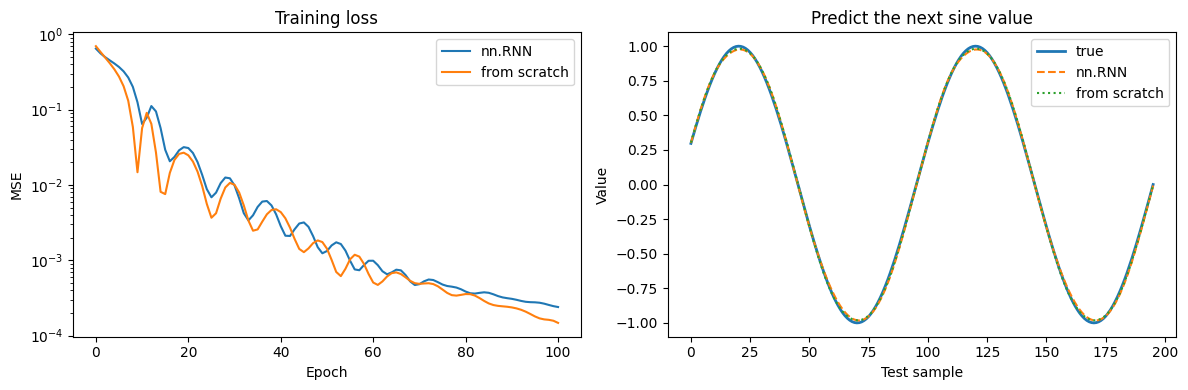

In [11]:
model.eval()
manual_model.eval()
with torch.no_grad():
    test_prediction = model(X_test)
    manual_prediction = manual_model(X_test)
    test_mse = loss_fn(test_prediction, y_test).item()
    manual_test_mse = loss_fn(manual_prediction, y_test).item()

print(f"nn.RNN test MSE:       {test_mse:.6f}")
print(f"From-scratch test MSE: {manual_test_mse:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_builtin, label="nn.RNN")
axes[0].plot(losses_manual, label="from scratch")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="MSE")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(y_test.cpu(), label="true", linewidth=2)
axes[1].plot(test_prediction.cpu(), "--", label="nn.RNN")
axes[1].plot(manual_prediction.cpu(), ":", label="from scratch")
axes[1].set(title="Predict the next sine value", xlabel="Test sample", ylabel="Value")
axes[1].legend()
plt.tight_layout()
plt.show()

## Takeaways

- The same RNN cell is reused at every time step.
- The hidden state carries a compressed memory of earlier inputs.
- Training uses backpropagation through time (BPTT).
- Vanilla RNNs can struggle with long-term dependencies; LSTMs and GRUs add gates to help.
- Transformers replace recurrence with attention, allowing time steps to interact directly and in parallel.

**Classroom experiment:** change `sequence_length` to 5 or 50, or replace `nn.RNN` with `nn.GRU`, and compare the test error.